In [1]:
import  numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.metrics import mean_squared_error as mse
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
from sklearn.kernel_ridge import KernelRidge
from sklearn.gaussian_process.kernels import ExpSineSquared, WhiteKernel
from sklearn.ensemble import RandomForestRegressor as RF

In [2]:
df= pd.read_csv('/content/xATGC.csv')
df

,TF,Max,Min,Mean,Target
0,5.880000e-08,0.000104,9.520000e+09,0.0467,xA
1,9.590000e-08,0.000169,1.550000e+10,0.0761,xA
2,1.640000e-07,0.000289,2.650000e+10,0.1300,xA
3,3.540000e-07,0.000624,5.730000e+10,0.2810,xA
4,1.190000e-06,0.002090,1.920000e+11,0.9440,xA
...,...,...,...,...,...
1995,4.030000e-10,0.000045,7.660000e+05,0.0200,xC
1996,4.080000e-10,0.000046,7.750000e+05,0.0202,xC
1997,4.130000e-10,0.000046,7.850000e+05,0.0204,xC
1998,4.180000e-10,0.000047,7.950000e+05,0.0207,xC


In [3]:
from sklearn.utils import shuffle
df1 = shuffle(df, random_state=42)
x_1 = df1.iloc[:,0:4]
x_1

,TF,Max,Min,Mean
1860,3.120000e-11,0.000003,59300.0,0.001540
353,2.010000e-09,0.000004,325000000.0,0.001600
1333,1.540000e-06,0.000387,3420.0,0.059100
905,3.400000e-08,0.000007,197000.0,0.002740
1289,2.590000e-07,0.000065,578.0,0.009980
...,...,...,...,...
1130,6.410000e-08,0.000016,143.0,0.002470
1294,2.510000e-07,0.000063,559.0,0.009660
860,9.640000e-09,0.000002,55700.0,0.000778
1459,1.070000e-05,0.002700,23900.0,0.412000


In [4]:
y_1 = df1["Target"]
y_1

,Target
1860,xC
353,xA
1333,xG
905,xT
1289,xG
...,...
1130,xG
1294,xG
860,xT
1459,xG


In [5]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_1, y_1, test_size=0.20, random_state=42)
x_train.to_csv("x_train.csv")
x_train

,TF,Max,Min,Mean
258,3.710000e-10,6.520000e-07,6.000000e+07,0.000294
743,1.510000e-07,3.000000e-05,8.750000e+05,0.012200
1393,4.280000e-05,1.080000e-02,9.530000e+04,1.650000
774,1.100000e-08,2.180000e-06,6.370000e+04,0.000889
650,9.300000e-09,1.840000e-06,5.380000e+04,0.000750
...,...,...,...,...
132,4.500000e-07,7.930000e-04,7.280000e+10,0.357000
1889,5.980000e-11,6.680000e-06,1.140000e+05,0.002960
869,8.500000e-09,1.680000e-06,4.910000e+04,0.000686
1212,1.560000e-07,3.940000e-05,3.480000e+02,0.006020


In [6]:
y_train.to_csv("y_train.csv")
y_train

,Target
258,xA
743,xT
1393,xG
774,xT
650,xT
...,...
132,xA
1889,xC
869,xT
1212,xG


In [7]:
x_test.to_csv("x_test.csv")
x_test

,TF,Max,Min,Mean
1522,4.400000e-07,0.049100,836000000.0,21.800000
1610,3.000000e-11,0.000003,57000.0,0.001480
568,3.250000e-07,0.000064,1880000.0,0.026200
1801,2.300000e-11,0.000003,43700.0,0.001140
90,3.780000e-09,0.000007,612000000.0,0.003000
...,...,...,...,...
1548,3.860000e-10,0.000043,735000.0,0.019100
652,1.090000e-08,0.000002,63000.0,0.000879
1636,1.540000e-11,0.000002,29300.0,0.000762
1911,1.950000e-10,0.000022,370000.0,0.009630


In [ ]:
y_test.to_csv("y-test.csv")
y_test

,Target
1522,xC
1610,xC
568,xT
1801,xC
90,xA
...,...
1548,xC
652,xT
1636,xC
1911,xC


## **KNN**

In [8]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=30)
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=30)

In [9]:
y_pred_knn = knn.predict(x_test)
from sklearn.metrics import accuracy_score

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_knn)))

Model accuracy score: 0.7825


In [10]:
print('Training set score: {:.4f}'.format(knn.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(knn.score(x_test, y_test)))

Training set score: 0.7631
Test set score: 0.7825


In [11]:
from sklearn.metrics import confusion_matrix

cm_kn = confusion_matrix(y_test,y_pred_knn)

In [12]:
knn.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 30,
 'p': 2,
 'weights': 'uniform'}

In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

          xA       0.88      0.99      0.93       106
          xC       0.62      0.65      0.63        96
          xG       0.94      0.85      0.89       107
          xT       0.65      0.60      0.63        91

    accuracy                           0.78       400
   macro avg       0.77      0.77      0.77       400
weighted avg       0.78      0.78      0.78       400



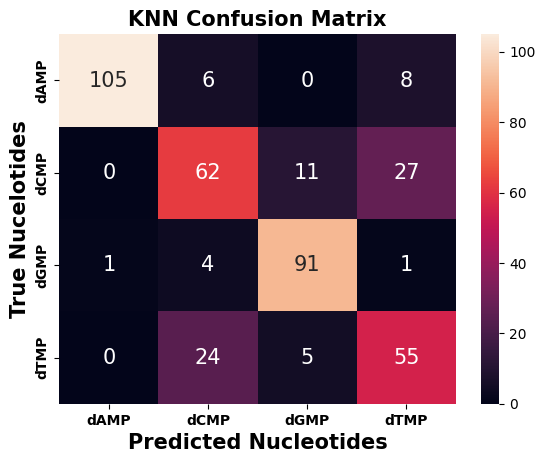

In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
cm = confusion_matrix(y_pred_knn, y_test)
cm_df = pd.DataFrame(cm,
                     index = ['dAMP','dCMP','dGMP', 'dTMP'],
                     columns = ['dAMP','dCMP','dGMP', 'dTMP'])

#sns.heatmap(cm_df, cbar=True,annot=True,cmap="PiYG",fmt="d",annot_kws={"size": 15})
sns.heatmap(cm_df, cbar=True,annot=True,fmt="d",annot_kws={"size": 15})

plt.ylabel('True Nucelotides', fontsize = 15,weight='bold')
plt.xlabel('Predicted Nucleotides', fontsize = 15,weight='bold')
plt.title('KNN Confusion Matrix', fontsize = 15,weight='bold')
plt.xticks(weight='bold')
plt.yticks(weight='bold')
plt.show()

## **SVM**

In [15]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svc=SVC()
svc.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [16]:
svc.fit(x_train,y_train)

SVC()

In [17]:
y_pred=svc.predict(x_test)
print('Model accuracy score with default hyperparameters: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score with default hyperparameters: 0.2275


In [18]:
print('Training set score: {:.4f}'.format(svc.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(svc.score(x_test, y_test)))

Training set score: 0.2581
Test set score: 0.2275


## **DTC_gini**

In [19]:
from sklearn.tree import DecisionTreeClassifier
# Assuming x_train, x_test, y_train, y_test are defined elsewhere in your code
dnn1 = DecisionTreeClassifier(criterion='gini', max_depth=23, random_state=65)
dnn1.fit(x_train, y_train)
y_pred_dnn1 = dnn1.predict(x_test)

In [20]:
print('Model accuracy score with criterion gini index: {0:0.4f}'. format(accuracy_score(y_test, y_pred_dnn1)))

Model accuracy score with criterion gini index: 0.9925


In [21]:
print('Training set score: {:.4f}'.format(dnn1.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(dnn1.score(x_test, y_test)))

Training set score: 0.9994
Test set score: 0.9925


In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dnn1))

              precision    recall  f1-score   support

          xA       0.99      1.00      1.00       106
          xC       0.99      0.99      0.99        96
          xG       1.00      0.99      1.00       107
          xT       0.99      0.99      0.99        91

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



In [23]:
dnn1.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 23,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': 65,
 'splitter': 'best'}

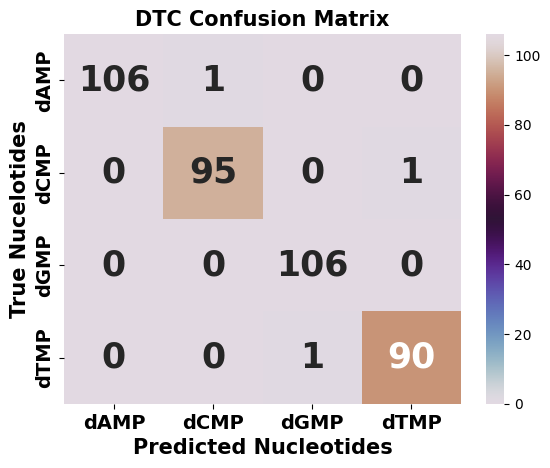

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
cm = confusion_matrix(y_pred_dnn1, y_test)
cm_df = pd.DataFrame(cm,
                     index = ['dAMP','dCMP','dGMP', 'dTMP'],
                     columns = ['dAMP','dCMP','dGMP', 'dTMP'])

#sns.heatmap(cm_df, cbar=True,annot=True,cmap="brg",fmt="d",annot_kws={"size": 15})
sns.heatmap(cm_df, cbar=True,annot=True,cmap="twilight", fmt="d",annot_kws={"size": 25, 'fontweight': 'bold'})

plt.ylabel('True Nucelotides', fontsize = 15,weight='bold')
plt.xlabel('Predicted Nucleotides', fontsize = 15,weight='bold')
plt.title('DTC Confusion Matrix', fontsize = 15,weight='bold')
plt.xticks(fontsize=14, weight='bold')
plt.yticks(fontsize=14, weight='bold')
plt.show()

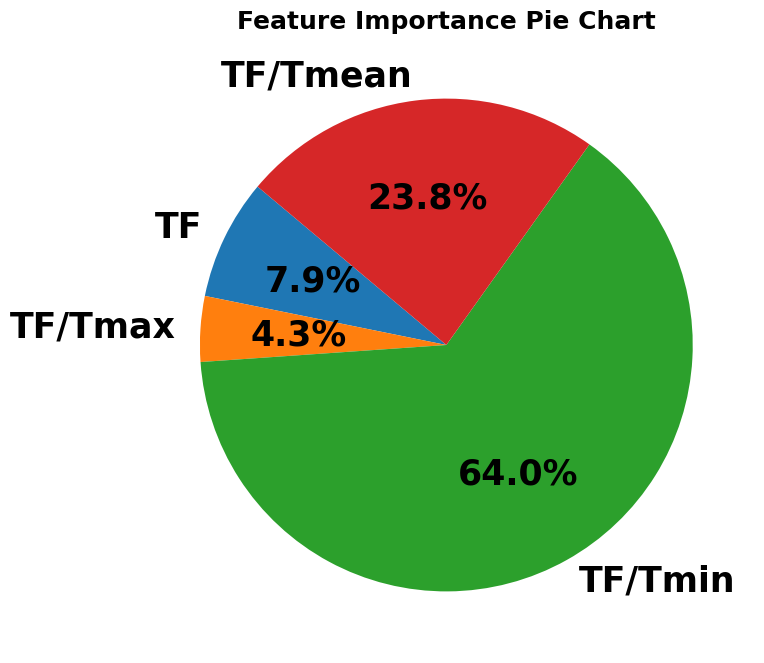

In [24]:
feature_importances = dnn1.feature_importances_

# Get the names of the features (replace with your feature names if available)
feature_names = ["TF", "TF/Tmax", "TF/Tmin", "TF/Tmean"]
# Create a pie chart
plt.figure(figsize=(8, 8))
patches, texts, autotexts = plt.pie(feature_importances, labels=feature_names, autopct='%1.1f%%', startangle=140,textprops={'fontsize': 54})

# Increase font size and make feature names bold
for text in texts + autotexts:
    text.set_size(25)  # Adjust the font size as needed
    text.set_weight('bold')

plt.title('Feature Importance Pie Chart', fontsize=18, weight='bold')
plt.show()

In [25]:
pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 14.6 MB/s eta 0:00:00


## **SHAP**

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Create the SHAP explainer with the trained model
explainer = shap.TreeExplainer(dnn1)  # Replace dnn1 with your actual tree-based model

# Compute SHAP values
shap_values = explainer.shap_values(x_test)

# Verify shapes
print("Shape of shap_values:", np.array(shap_values).shape)
print("Shape of x_test:", x_test.shape)

# Select the feature to plot
feature_to_plot = "TF"  # Replace with your feature name
if feature_to_plot in feature_names:
    feature_index = feature_names.index(feature_to_plot)

    # Plot the SHAP dependence scatter plot
    shap.dependence_plot(feature_index, shap_values[0], x_test, feature_names=feature_names)
    plt.show()
else:
    print(f"Feature '{feature_to_plot}' not found in the feature names.")


Shape of shap_values: (400, 4, 4)
Shape of x_test: (400, 4)


IndexError: index 4 is out of bounds for axis 0 with size 4

## **CV**

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier  # Replace with your actual model
#X = x_train
#y = y_train

num_folds = 10

kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(dnn1, x_1, y_1, cv=kf, scoring='accuracy')

for i, accuracy in enumerate(accuracy_scores):
    print(f'Fold {i + 1} Accuracy: {accuracy:.4f}')
mean_accuracy = accuracy_scores.mean()
std_dev_accuracy = accuracy_scores.std()
print(f'\nMean Accuracy: {mean_accuracy:.4f} (±{std_dev_accuracy:.4f})')

Fold 1 Accuracy: 0.9800
Fold 2 Accuracy: 0.9850
Fold 3 Accuracy: 0.9950
Fold 4 Accuracy: 0.9850
Fold 5 Accuracy: 0.9800
Fold 6 Accuracy: 0.9850
Fold 7 Accuracy: 0.9850
Fold 8 Accuracy: 0.9800
Fold 9 Accuracy: 0.9700
Fold 10 Accuracy: 0.9850

Mean Accuracy: 0.9830 (±0.0060)


## **ROC_AUC**

In [ ]:
from sklearn.metrics import roc_curve, auc

No positive samples in y_true, true positive value should be meaningless
No positive samples in y_true, true positive value should be meaningless
No positive samples in y_true, true positive value should be meaningless
No positive samples in y_true, true positive value should be meaningless


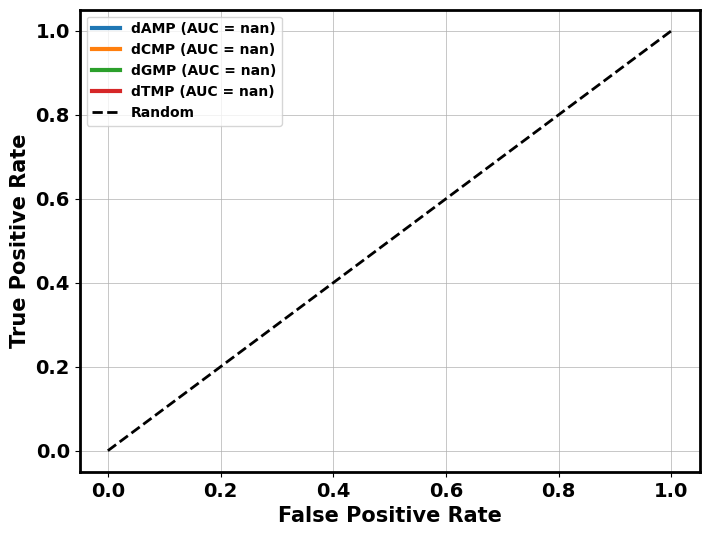

In [ ]:
dnn1.fit(x_train, y_train)

# Get probabilities for each class
y_score = dnn1.predict_proba(x_test)

# Get the number of unique classes in y
n_classes = len(np.unique(y_train))

# Assign class names to the classes
class_names = {0: 'dAMP', 1: 'dCMP', 2: 'dGMP', 3: 'dTMP'}

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    # Convert labels to binary for each class
    y_binary = (y_test == i).astype(int)

    fpr[i], tpr[i], _ = roc_curve(y_binary, y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})', linewidth=3)

plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=2)
plt.xlabel('False Positive Rate', fontsize = 15,weight='bold')
plt.ylabel('True Positive Rate', fontsize = 15,weight='bold')
#plt.title('ROC Curve for Multiclass Classification', fontsize = 18,weight='bold')
plt.grid(which='both', linestyle='-', linewidth=0.5)
plt.xticks(fontsize=14, weight='bold')
plt.yticks(fontsize=14, weight='bold')
ax = plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.legend(loc='best')
plt.rcParams['font.weight'] = 'bold'
plt.show()

## **DTC_entropy**

In [26]:
dnn = DecisionTreeClassifier(criterion='entropy', max_depth=22, random_state=35)
dnn.fit(x_train, y_train)
y_pred_dnn = dnn.predict(x_test)

In [ ]:
print('Model accuracy score with criterion gini index: {0:0.4f}'. format(accuracy_score(y_test, y_pred_dnn)))

Model accuracy score with criterion gini index: 0.9975


In [ ]:
print('Training set score: {:.4f}'.format(dnn.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(dnn.score(x_test, y_test)))

Training set score: 0.9994
Test set score: 0.9975


In [ ]:
dnn.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'entropy',
 'max_depth': 22,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': 35,
 'splitter': 'best'}

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dnn))

              precision    recall  f1-score   support

          xA       0.99      1.00      1.00       106
          xC       1.00      1.00      1.00        96
          xG       1.00      1.00      1.00       107
          xT       1.00      0.99      0.99        91

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



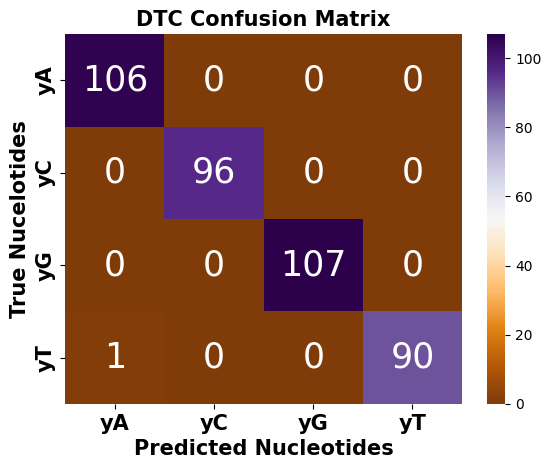

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_dnn)
cm_df = pd.DataFrame(cm,
                     index = ['yA','yC','yG', 'yT'],
                     columns = ['yA','yC','yG', 'yT'])

sns.heatmap(cm_df, cbar=True,annot=True,cmap="PuOr",fmt="d",annot_kws={"size": 25})
plt.ylabel('True Nucelotides', fontsize = 15,weight='bold')
plt.xlabel('Predicted Nucleotides', fontsize = 15,weight='bold')
plt.title('DTC Confusion Matrix', fontsize = 15,weight='bold')
plt.xticks(fontsize=15,weight='bold')
plt.yticks(fontsize=15,weight='bold')
plt.show()

In [29]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier  # Replace with your actual model
#X = x_train
#y = y_train

num_folds = 10

kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(dnn, x_1, y_1, cv=kf, scoring='accuracy')

for i, accuracy in enumerate(accuracy_scores):
    print(f'Fold {i + 1} Accuracy: {accuracy:.4f}')
mean_accuracy = accuracy_scores.mean()
std_dev_accuracy = accuracy_scores.std()
print(f'\nMean Accuracy: {mean_accuracy:.4f} (±{std_dev_accuracy:.4f})')

Fold 1 Accuracy: 1.0000
Fold 2 Accuracy: 0.9950
Fold 3 Accuracy: 0.9900
Fold 4 Accuracy: 0.9900
Fold 5 Accuracy: 0.9850
Fold 6 Accuracy: 0.9800
Fold 7 Accuracy: 0.9850
Fold 8 Accuracy: 0.9900
Fold 9 Accuracy: 0.9700
Fold 10 Accuracy: 0.9950

Mean Accuracy: 0.9880 (±0.0081)


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

# Generating synthetic data with four classes using make_classification
x, y = make_classification(
    n_samples=2000,
    n_features=4,
    n_classes=4,
    n_clusters_per_class=1,
    random_state=42
)

# Splitting the data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Initialize the RandomForestClassifier (or any classifier of your choice)
#model = DecisionTreeClassifier()

# Train the model
dnn.fit(x_train, y_train)

# Get probabilities for each class
y_score = model.predict_proba(x_test)

# Get the number of unique classes in y
n_classes = len(np.unique(y))
# Assign class names to the classes
class_names = {0: 'yA', 1: 'yC', 2: 'yG', 3: 'yT'}

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
#plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})', linewidth=3)
    #plt.plot(fpr[i], tpr[i], label=f'class_names=class_names')

plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=2)
plt.xlabel('False Positive Rate', fontsize = 15,weight='bold')
plt.ylabel('True Positive Rate', fontsize = 15,weight='bold')
#plt.title('ROC Curve for Multiclass Classification', fontsize = 18,weight='bold')
plt.grid(which='both', linestyle='-', linewidth=0.5)
plt.xticks(fontsize=14, weight='bold')
plt.yticks(fontsize=14, weight='bold')
ax = plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.legend(loc='best')
plt.rcParams['font.weight'] = 'bold'
plt.show()

NameError: name 'model' is not defined

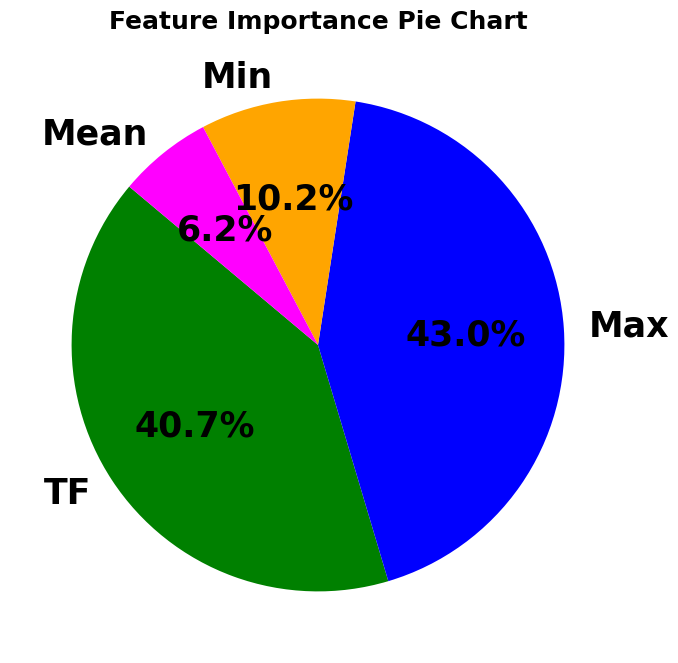

In [30]:
feature_importances = dnn.feature_importances_

# Get the names of the features (replace with your feature names if available)
feature_names = ["TF", "Max", "Min", "Mean"]
# Create a pie chart
plt.figure(figsize=(8, 8))
patches, texts, autotexts = plt.pie(feature_importances, labels=feature_names, autopct='%1.1f%%', startangle=140,textprops={'fontsize': 54}, colors=['green', 'blue', 'orange','magenta'])

# Increase font size and make feature names bold
for text in texts + autotexts:
    text.set_size(25)  # Adjust the font size as needed
    text.set_weight('bold')

plt.title('Feature Importance Pie Chart', fontsize=18, weight='bold')
plt.show()

Shape of shap_values: (400, 4, 4)
Type of shap_values: <class 'numpy.ndarray'>


TypeError: only integer scalar arrays can be converted to a scalar index

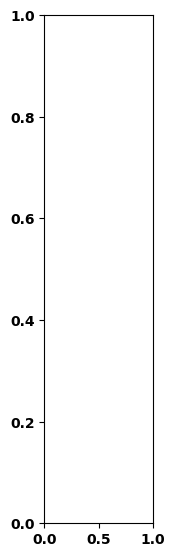

In [35]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#feature_names = list(x_test.columns) # This line might be causing the issue if x_test is not a pandas DataFrame
class_names = ['yA','yC','yG','yT']

# Create the SHAP explainer with the trained model
explainer = shap.TreeExplainer(dnn)

# Compute SHAP valuesfc
shap_values = explainer.shap_values(x_test)
class_colors = ["#E69F00", "#56B4E9", "#D55E00", "#0073C2"]
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['text.color'] = 'black'

# Ensure feature_names is a list of strings
feature_names = ["TF", "Max", "Min", "Mean"]  # Or get feature names from your data source
print("Shape of shap_values:", shap_values.shape)
print("Type of shap_values:", type(shap_values))
# Plot the SHAP summary plot
shap.summary_plot(shap_values, x_test, plot_type="bar", class_names=class_names, feature_names=feature_names)
plt.show()

In [ ]:
pip install scikit-learn graphviz

In [ ]:
from sklearn.tree import export_graphviz
import graphviz

In [ ]:
export_graphviz(dnn, out_file='tree.dot',
                feature_names=["TF", "Max", "Min", "Mean"],
                class_names=['yA','yC','yG','yT'],
                filled=True, rounded=True,
                special_characters=True)

# Convert the Graphviz file to a PNG image
with open("tree.dot") as f:
    dot_graph = f.read()
graphviz.Source(dot_graph).render("decision_tree", format="png", cleanup=True)

'decision_tree.png'

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
target = df1.Target.values

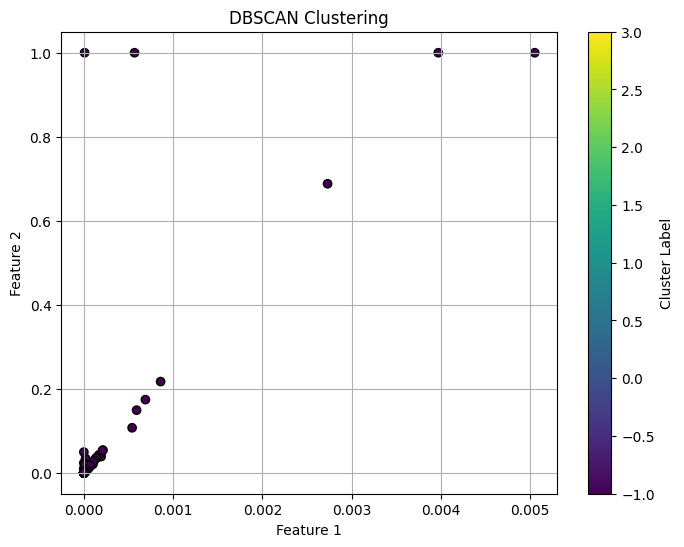

In [ ]:
# Importing required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs

# Generate sample data
#X, _ = make_blobs(n_samples=1000, centers=2, random_state=42)
X = x_1.values

# Perform DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(X)

# Plotting the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', marker='o', edgecolors='k')
plt.title('DBSCAN Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
plt.grid(True)
plt.show()

## **RFC**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
RandomForestClassifier().get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [ ]:
rfc = RandomForestClassifier(criterion = 'entropy', random_state=100, max_depth = 25)

In [ ]:
rfc.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'entropy',
 'max_depth': 25,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 100,
 'verbose': 0,
 'warm_start': False}

In [ ]:
rfc.fit(x_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=25, random_state=100)

In [ ]:
y_pred_rf = rfc.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

print('Model accuracy score with 10 decision-trees : {0:0.4f}'. format(accuracy_score(y_test, y_pred_rf)))

Model accuracy score with 10 decision-trees : 0.9950


In [ ]:
print('Training set score: {:.4f}'.format(rfc.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(rfc.score(x_test, y_test)))

Training set score: 1.0000
Test set score: 0.9933


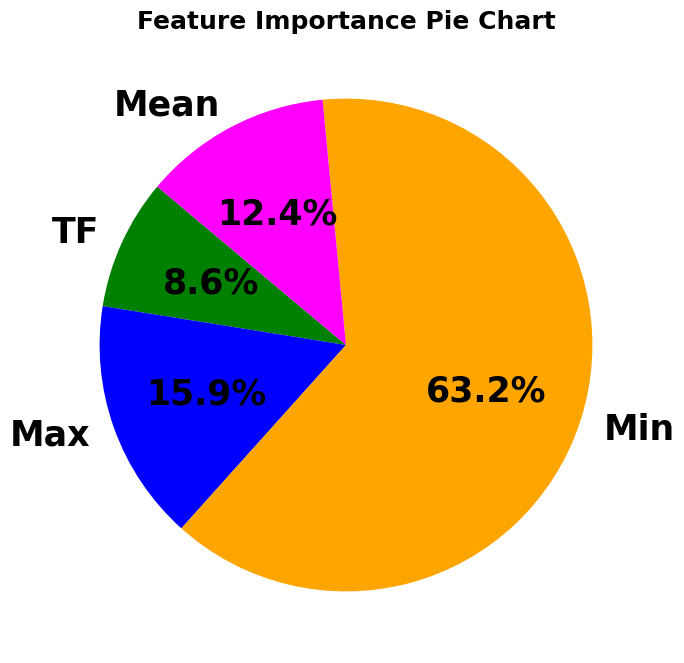

In [ ]:
feature_importances = rfc.feature_importances_

# Get the names of the features (replace with your feature names if available)
feature_names = ["TF", "Max", "Min", "Mean"]
# Create a pie chart
plt.figure(figsize=(8, 8))
patches, texts, autotexts = plt.pie(feature_importances, labels=feature_names, autopct='%1.1f%%', startangle=140,textprops={'fontsize': 54}, colors=['green', 'blue', 'orange','magenta'])

# Increase font size and make feature names bold
for text in texts + autotexts:
    text.set_size(25)  # Adjust the font size as needed
    text.set_weight('bold')

plt.title('Feature Importance Pie Chart', fontsize=18, weight='bold')
plt.show()

In [ ]:
import numpy as np

In [ ]:
feature_scores = pd.Series(rfc.feature_importances_, index=pd.DataFrame(x_train).columns).sort_values(ascending=False)
feature_scores

Min     0.681633
Max     0.180676
Mean    0.094324
TF      0.043367
dtype: float64

In [ ]:
rfc.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'entropy',
 'max_depth': 25,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 100,
 'verbose': 0,
 'warm_start': False}

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       107
           1       0.98      1.00      0.99       101
           2       1.00      0.99      0.99        92

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



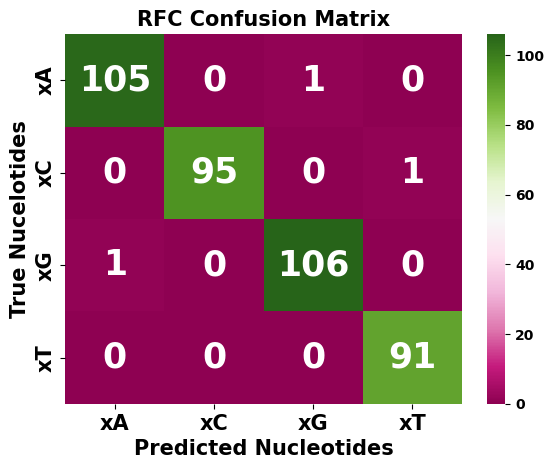

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Assuming y_test and y_pred_rf are defined

cm = confusion_matrix(y_test, y_pred_rf)
cm_df = pd.DataFrame(cm,
                     index=['xA', 'xC', 'xG', 'xT'],
                     columns=['xA', 'xC', 'xG', 'xT'])
colors = ['red', 'yellow']
# Create heatmap with bold annotations
sns.heatmap(cm_df, cbar=True,annot=True,cmap="PiYG", fmt="d",annot_kws={"size": 25, 'fontweight': 'bold'})

plt.ylabel('True Nucelotides', fontsize = 15,weight='bold')
plt.xlabel('Predicted Nucleotides', fontsize = 15,weight='bold')
plt.title('RFC Confusion Matrix', fontsize = 15,weight='bold')
plt.xticks(fontsize=15, weight='bold')
plt.yticks(fontsize=15, weight='bold')
plt.show()


## **ROC_AUC**

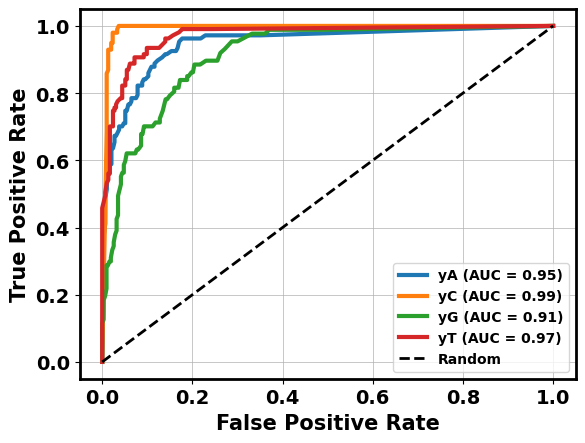

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

# Generating synthetic data with four classes using make_classification
x, y = make_classification(
    n_samples=2000,
    n_features=4,
    n_classes=4,
    n_clusters_per_class=1,
    random_state=42
)

# Splitting the data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Initialize the RandomForestClassifier (or any classifier of your choice)
#model = RandomForestClassifier()

# Train the model
rfc.fit(x_train, y_train)

# Get probabilities for each class
y_score = model.predict_proba(x_test)

# Get the number of unique classes in y
n_classes = len(np.unique(y))
# Assign class names to the classes
class_names = {0: 'yA', 1: 'yC', 2: 'yG', 3: 'yT'}

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
#plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})', linewidth=3)
    #plt.plot(fpr[i], tpr[i], label=f'class_names=class_names')

plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=2)
plt.xlabel('False Positive Rate', fontsize = 15,weight='bold')
plt.ylabel('True Positive Rate', fontsize = 15,weight='bold')
#plt.title('ROC Curve for Multiclass Classification', fontsize = 18,weight='bold')
plt.grid(which='both', linestyle='-', linewidth=0.5)
plt.xticks(fontsize=14, weight='bold')
plt.yticks(fontsize=14, weight='bold')
ax = plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.legend(loc='best')
plt.rcParams['font.weight'] = 'bold'
plt.show()


# **Cross_Validation**

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier  # Replace with your actual model
#X = x_train
#y = y_train

num_folds = 10

kf = KFold(n_splits=num_folds, shuffle=True, random_state=65)

accuracy_scores = cross_val_score(rfc, x_1, y_1, cv=kf, scoring='accuracy')

for i, accuracy in enumerate(accuracy_scores):
    print(f'Fold {i + 1} Accuracy: {accuracy:.4f}')
mean_accuracy = accuracy_scores.mean()
std_dev_accuracy = accuracy_scores.std()
print(f'\nMean Accuracy: {mean_accuracy:.4f} (±{std_dev_accuracy:.4f})')


Fold 1 Accuracy: 1.0000
Fold 2 Accuracy: 0.9850
Fold 3 Accuracy: 0.9950
Fold 4 Accuracy: 0.9900
Fold 5 Accuracy: 0.9900
Fold 6 Accuracy: 0.9900
Fold 7 Accuracy: 1.0000
Fold 8 Accuracy: 0.9850
Fold 9 Accuracy: 0.9950
Fold 10 Accuracy: 0.9900

Mean Accuracy: 0.9920 (±0.0051)


## **Unknown Prediction**

In [ ]:
df5= pd.read_csv('/content/12.csv')
x_t = df5.iloc[:,0:4]
y_t = df5["Target"]

In [ ]:
y_pred_t = rfc.predict(x_t)
print('Model accuracy score with 10 decision-trees : {0:0.4f}'. format(accuracy_score(y_t, y_pred_t)))

Model accuracy score with 10 decision-trees : 0.1800


In [ ]:
y_pred_t

array(['xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG',
       'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG',
       'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG',
       'xT', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG',
       'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG',
       'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xT', 'xG', 'xG', 'xG',
       'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG',
       'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG',
       'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG',
       'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG',
       'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG',
       'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG',
       'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG',
       'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'xG', 'x

In [ ]:
from google.colab import files
import pandas as pd
df = pd.DataFrame(y_pred_t)
df.to_csv('xG_pred.csv')
files.download('xG_pred.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **shap**

In [ ]:
!pip install shap

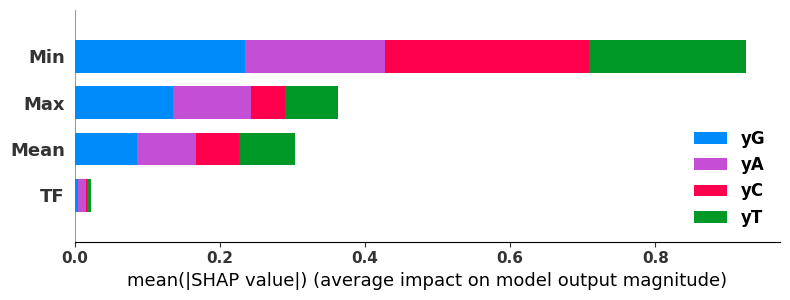

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
#feature_names = list(x_test.columns)
class_names = ['yA','yC','yG','yT']

# Create the SHAP explainer with the trained model
explainer = shap.TreeExplainer(rfc)

# Compute SHAP values
shap_values = explainer.shap_values(x_test)
class_colors = ["#E69F00", "#56B4E9", "#D55E00", "#0073C2"]
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['text.color'] = 'black'
# Plot the SHAP summary plot
shap.summary_plot(shap_values, x_test, plot_type="bar", class_names=class_names, feature_names=feature_names)
plt.show()

## **Logistic Regression Model**

In [ ]:
# train a logistic regression model on the training set
from sklearn.linear_model import LogisticRegression


# instantiate the model
logreg = LogisticRegression(solver='lbfgs', random_state=35)


# fit the model
logreg.fit(x_train, y_train)

LogisticRegression(random_state=35)

In [ ]:
logreg.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'auto',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': 35,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [ ]:
y_pred_logistic = logreg.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_logistic)))

Model accuracy score: 0.2650


In [ ]:
print('Training set score: {:.4f}'.format(logreg.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(logreg.score(x_test, y_test)))

Training set score: 0.2462
Test set score: 0.2650


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.77      0.74      0.75       107
           1       0.84      0.90      0.87        99
           2       0.72      0.70      0.71        87
           3       0.86      0.85      0.85       107

    accuracy                           0.80       400
   macro avg       0.80      0.80      0.80       400
weighted avg       0.80      0.80      0.80       400



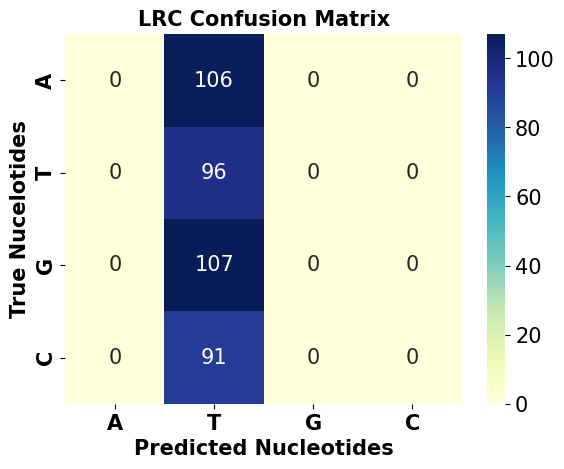

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_logistic)
cm_df = pd.DataFrame(cm,
                     index = ['A','T','G', 'C'],
                     columns = ['A','T','G', 'C'])

sns.heatmap(cm_df, cbar=True,annot=True,cmap="YlGnBu",fmt="d",annot_kws={"size": 15})
plt.ylabel('True Nucelotides', fontsize = 15,weight='bold')
plt.xlabel('Predicted Nucleotides', fontsize = 15,weight='bold')
plt.title('LRC Confusion Matrix', fontsize = 15,weight='bold')
plt.xticks(weight='bold')
plt.yticks(weight='bold')
plt.show()

## **Validation Parameters**

In [ ]:
feature_scores = pd.Series(rfc.feature_importances_, index=x_train.columns).sort_values(ascending=False)
feature_scores

Min     0.489226
Mean    0.196832
TF      0.170668
Max     0.143274
dtype: float64

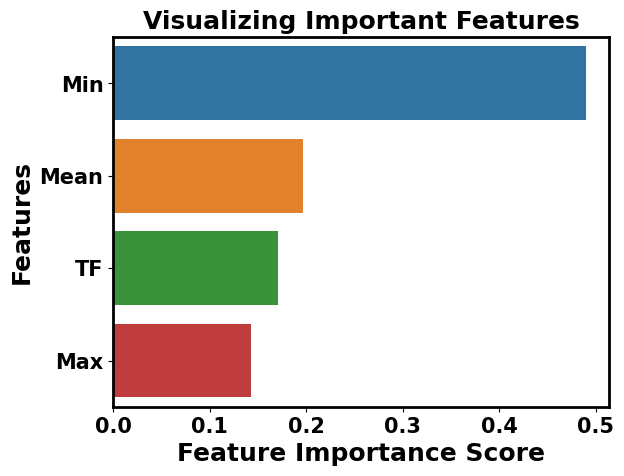

In [ ]:
sns.barplot(x=feature_scores, y=feature_scores.index)
plt.xlabel('Feature Importance Score', fontsize = 18,weight='bold')
plt.xticks(weight='bold')
plt.yticks(weight='bold')
plt.ylabel('Features', fontsize = 18,weight='bold')
plt.title("Visualizing Important Features", fontsize = 18,weight='bold')
plt.show()

## **Gaussian Naive Bayes**

In [ ]:
from sklearn.naive_bayes import GaussianNB
model_naive = GaussianNB()
model_naive.fit(x_train, y_train)

GaussianNB()

In [ ]:
model_naive.get_params()

{'priors': None, 'var_smoothing': 1e-09}

In [ ]:
y_pred_naive = model_naive.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_naive)))

Model accuracy score: 0.3425


In [ ]:
print('Training set score: {:.4f}'.format(model_naive.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(model_naive.score(x_test, y_test)))

Training set score: 0.3237
Test set score: 0.3425


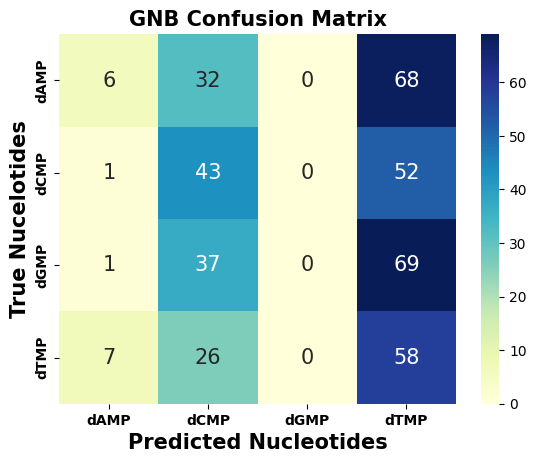

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_naive)
cm_df = pd.DataFrame(cm,
                     index = ['dAMP','dCMP','dGMP', 'dTMP'],
                     columns = ['dAMP','dCMP','dGMP', 'dTMP'])

sns.heatmap(cm_df, cbar=True,annot=True,cmap="YlGnBu",fmt="d",annot_kws={"size": 15})
plt.ylabel('True Nucelotides', fontsize = 15,weight='bold')
plt.xlabel('Predicted Nucleotides', fontsize = 15,weight='bold')
plt.title('GNB Confusion Matrix', fontsize = 15,weight='bold')
plt.xticks(weight='bold')
plt.yticks(weight='bold')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_naive))

              precision    recall  f1-score   support

           0       0.80      0.86      0.83       107
           1       0.94      0.93      0.93        99
           2       0.76      0.68      0.72        87
           3       0.86      0.88      0.87       107

    accuracy                           0.84       400
   macro avg       0.84      0.84      0.84       400
weighted avg       0.84      0.84      0.84       400



## **GPR**

In [ ]:
from sklearn.gaussian_process import GaussianProcessClassifier
classifier = GaussianProcessClassifier()

In [ ]:
classifier.fit(x_train, y_train)

GaussianProcessClassifier()

In [ ]:
y_pred_gpr = classifier.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_gpr)))

Model accuracy score: 0.4200


In [ ]:
print('Training set score: {:.4f}'.format(classifier.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(classifier.score(x_test, y_test)))

Training set score: 0.9856
Test set score: 0.4200


In [ ]:
classifier.get_params()

{'copy_X_train': True,
 'kernel': None,
 'max_iter_predict': 100,
 'multi_class': 'one_vs_rest',
 'n_jobs': None,
 'n_restarts_optimizer': 0,
 'optimizer': 'fmin_l_bfgs_b',
 'random_state': None,
 'warm_start': False}

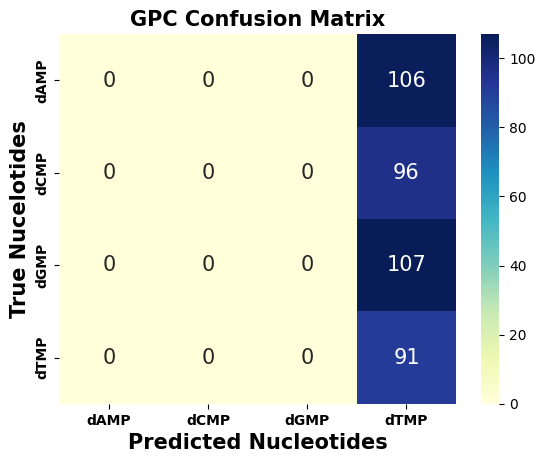

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_gpr)
cm_df = pd.DataFrame(cm,
                     index = ['dAMP','dCMP','dGMP', 'dTMP'],
                     columns = ['dAMP','dCMP','dGMP', 'dTMP'])

sns.heatmap(cm_df, cbar=True,annot=True,cmap="YlGnBu",fmt="d",annot_kws={"size": 15})
plt.ylabel('True Nucelotides', fontsize = 15,weight='bold')
plt.xlabel('Predicted Nucleotides', fontsize = 15,weight='bold')
plt.title('GPC Confusion Matrix', fontsize = 15,weight='bold')
plt.xticks(weight='bold')
plt.yticks(weight='bold')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_gpr))

              precision    recall  f1-score   support

        dAMP       0.00      0.00      0.00       106
        dCMP       0.00      0.00      0.00        96
        dGMP       0.00      0.00      0.00       107
        dTMP       0.23      1.00      0.37        91

    accuracy                           0.23       400
   macro avg       0.06      0.25      0.09       400
weighted avg       0.05      0.23      0.08       400



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## **Stochastic Gradient Descent Classifier**

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier()

sgd.fit(x_train, y_train)

SGDClassifier()

In [ ]:
y_pred_sgd = sgd.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_sgd)))

Model accuracy score: 0.7850


In [ ]:
print('Training set score: {:.4f}'.format(sgd.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(sgd.score(x_test, y_test)))

Training set score: 0.7913
Test set score: 0.7850


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_sgd))

              precision    recall  f1-score   support

           0       0.76      0.80      0.78       107
           1       0.92      0.82      0.87        99
           2       0.62      0.80      0.70        87
           3       0.89      0.72      0.79       107

    accuracy                           0.79       400
   macro avg       0.80      0.79      0.79       400
weighted avg       0.80      0.79      0.79       400



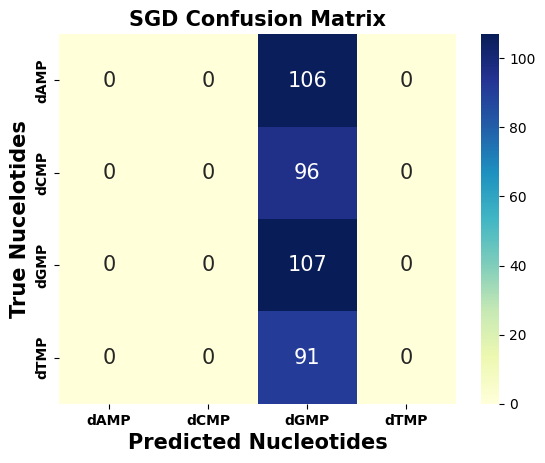

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_sgd)
cm_df = pd.DataFrame(cm,
                     index = ['dAMP','dCMP','dGMP', 'dTMP'],
                     columns = ['dAMP','dCMP','dGMP', 'dTMP'])

sns.heatmap(cm_df, cbar=True,annot=True,cmap="YlGnBu",fmt="d",annot_kws={"size": 15})
plt.ylabel('True Nucelotides', fontsize = 15,weight='bold')
plt.xlabel('Predicted Nucleotides', fontsize = 15,weight='bold')
plt.title('SGD Confusion Matrix', fontsize = 15,weight='bold')
plt.xticks(weight='bold')
plt.yticks(weight='bold')
plt.show()

In [ ]:
sgd.get_params()

{'alpha': 0.0001,
 'average': False,
 'class_weight': None,
 'early_stopping': False,
 'epsilon': 0.1,
 'eta0': 0.0,
 'fit_intercept': True,
 'l1_ratio': 0.15,
 'learning_rate': 'optimal',
 'loss': 'hinge',
 'max_iter': 1000,
 'n_iter_no_change': 5,
 'n_jobs': None,
 'penalty': 'l2',
 'power_t': 0.5,
 'random_state': None,
 'shuffle': True,
 'tol': 0.001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}